<a href="https://colab.research.google.com/github/sohanreddys/Visualization_Assignment_160123733059/blob/main/160123733059.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDAV — Exploratory Data Analysis & Visualisation Assignment 2
> **Dataset:** Kaggle Sample Superstore  https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

> **Tools:** pandas · matplotlib · seaborn · scipy  

> **Author:** *Sohan Reddy Seelam*

---

In [14]:
from google.colab import files
uploaded = files.upload()   # pick Sample - Superstore.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Global style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

COLORS  = {"Furniture": "#E07B54", "Office Supplies": "#5B8DB8", "Technology": "#6AAB72"}
REGIONS = ["West", "East", "Central", "South"]
CAT_PAL = list(COLORS.values())
REGION_PAL = {"West": "#5B8DB8", "East": "#6AAB72", "Central": "#E07B54", "South": "#B58DB8"}
SEG_PAL    = {"Consumer": "#5B8DB8", "Corporate": "#6AAB72", "Home Office": "#E07B54"}

# ── Load ─────────────────────────────────────────────────────
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1",
                 parse_dates=["Order Date", "Ship Date"])

df["Month"]    = df["Order Date"].dt.to_period("M")
df["Year"]     = df["Order Date"].dt.year
df["MonthNum"] = df["Order Date"].dt.month

print("Shape:", df.shape)
df[["Sales","Profit","Discount","Quantity"]].describe().round(2)

Saving Sample - Superstore.csv to Sample - Superstore (1).csv
Shape: (9994, 24)


,Sales,Profit,Discount,Quantity
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16,3.79
std,623.25,234.26,0.21,2.23
min,0.44,-6599.98,0.00,1.00
25%,17.28,1.73,0.00,2.00
50%,54.49,8.67,0.20,3.00
75%,209.94,29.36,0.20,5.00
max,22638.48,8399.98,0.80,14.00


---
## Q1 — Monthly Sales Trend by Category (All Years)

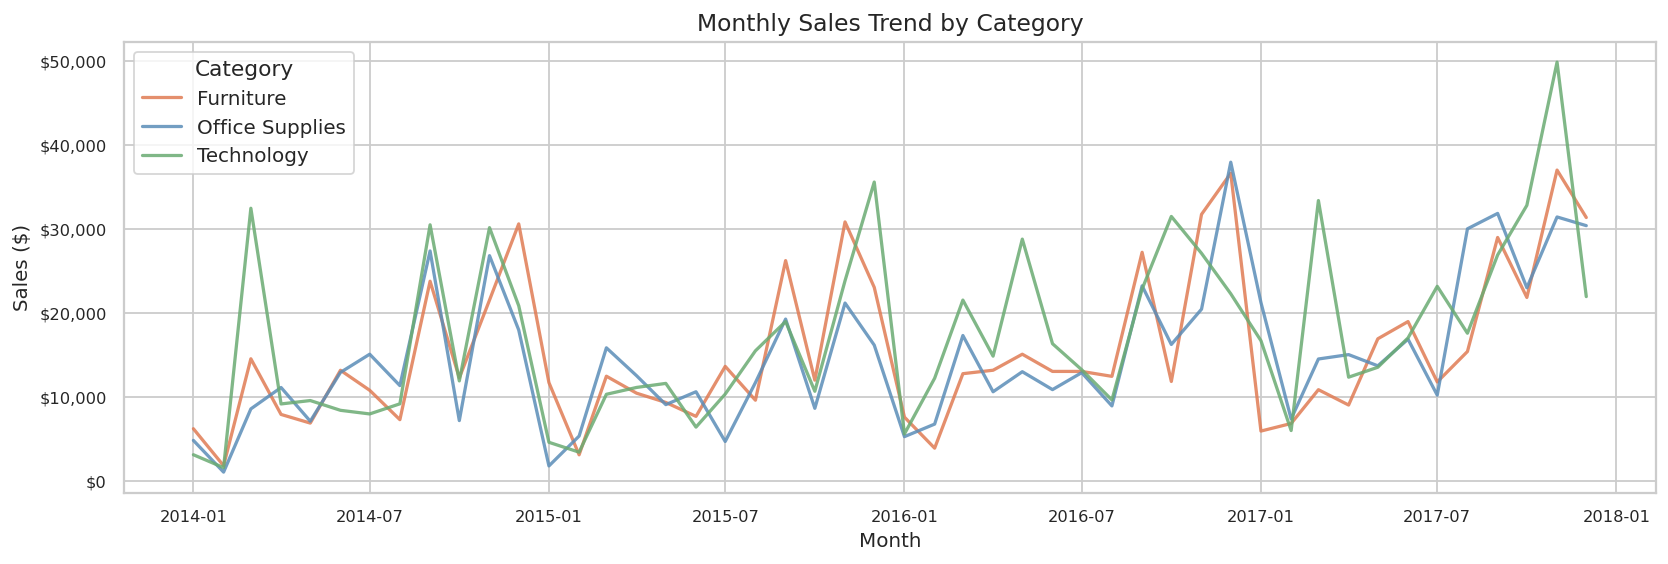

In [15]:
monthly = (
    df.groupby(["Month", "Category"])["Sales"]
      .sum()
      .reset_index()
)
monthly["Month_dt"] = monthly["Month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4.5))
for cat, grp in monthly.groupby("Category"):
    ax.plot(grp["Month_dt"], grp["Sales"], label=cat,
            color=COLORS[cat], linewidth=1.8, alpha=0.85)

ax.set_title("Monthly Sales Trend by Category")
ax.set_xlabel("Month"); ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Category")
plt.tight_layout()
plt.show()

**Insights**
- **Technology** spikes sharply around Q4 each year — likely seasonal corporate budget flush-outs before year-end.
- **Office Supplies** stays the flattest and most consistent, reflecting routine operational restocking with no strong seasonal pull.

---
## Q2 — Discount vs Profit Scatter (Colored by Category)

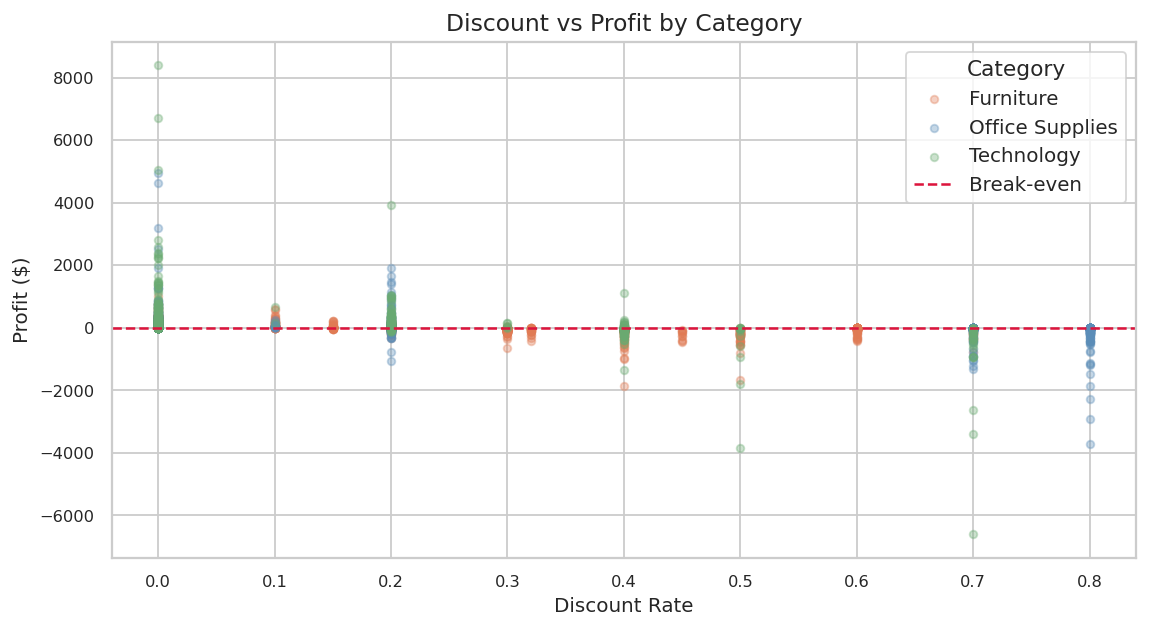

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
for cat, grp in df.groupby("Category"):
    ax.scatter(grp["Discount"], grp["Profit"],
               alpha=0.35, s=18, label=cat, color=COLORS[cat])

ax.axhline(0, color="crimson", linewidth=1.4, linestyle="--", label="Break-even")
ax.set_title("Discount vs Profit by Category")
ax.set_xlabel("Discount Rate"); ax.set_ylabel("Profit ($)")
ax.legend(title="Category")
plt.tight_layout()
plt.show()

**Insights**
- Discounts beyond **~40%** push orders below the break-even line across every category — aggressive discounting is reliably loss-making.
- **Furniture** clusters into losses even at moderate discounts, revealing thin margins that leave almost no room for any markdown.

---
## Q3 — Sales Histogram with KDE

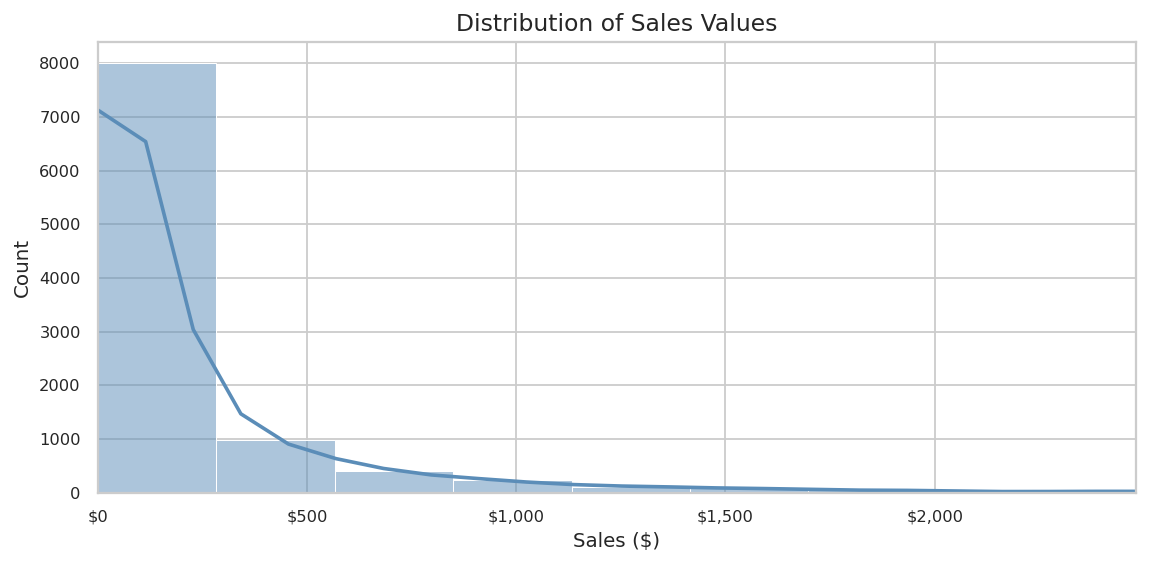

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["Sales"], bins=80, kde=True, color="#5B8DB8",
             ax=ax, line_kws={"linewidth": 2})
ax.set_xlim(0, df["Sales"].quantile(0.99))
ax.set_title("Distribution of Sales Values")
ax.set_xlabel("Sales ($)"); ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

**Insights**
- Sales are **heavily right-skewed** — the bulk of orders sit below $500, while a long tail of high-value orders inflates the mean well above the median.
- The unimodal KDE shows no secondary peak, meaning there isn't a clearly separate "premium-order" cluster — large orders appear as a smooth tapering tail.

---
## Q4 — Profit KDE by Region

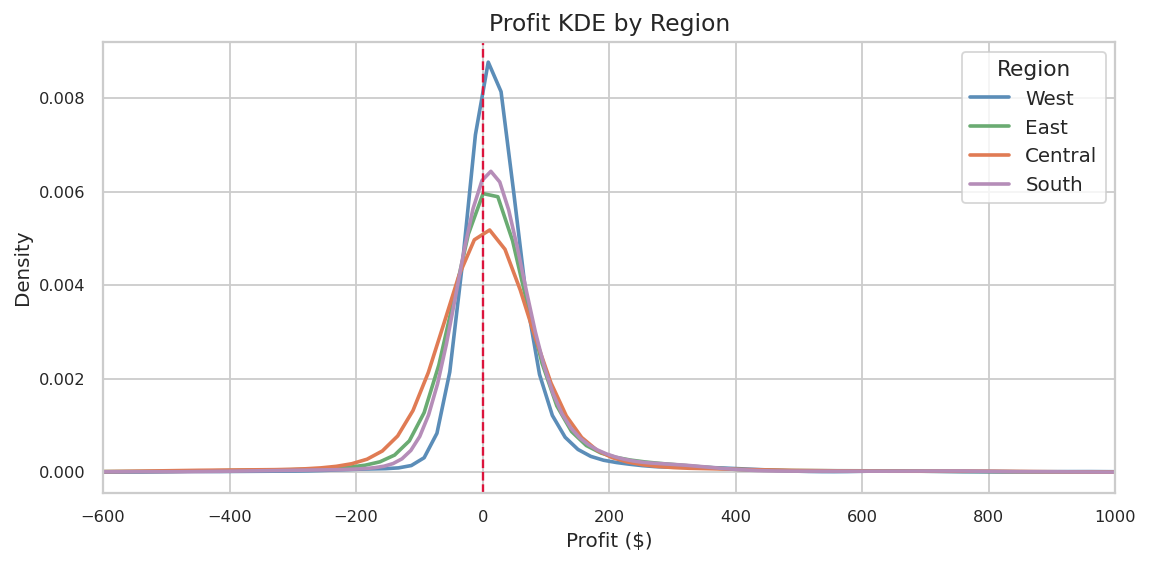

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for region in REGIONS:
    sub = df[df["Region"] == region]["Profit"]
    sub.plot.kde(ax=ax, label=region, linewidth=2, color=REGION_PAL[region])

ax.axvline(0, color="crimson", linestyle="--", linewidth=1.3)
ax.set_xlim(-600, 1000)
ax.set_title("Profit KDE by Region")
ax.set_xlabel("Profit ($)"); ax.set_ylabel("Density")
ax.legend(title="Region")
plt.tight_layout()
plt.show()

**Insights**
- **Central** has the widest, flattest KDE — highest variance among all regions, generating both the worst losses and some big wins.
- **West** and **East** peak more firmly in positive territory, indicating more consistently profitable operations compared to Central and South.

---
## Q5 — Sales vs Profit KDE Subplots by Category

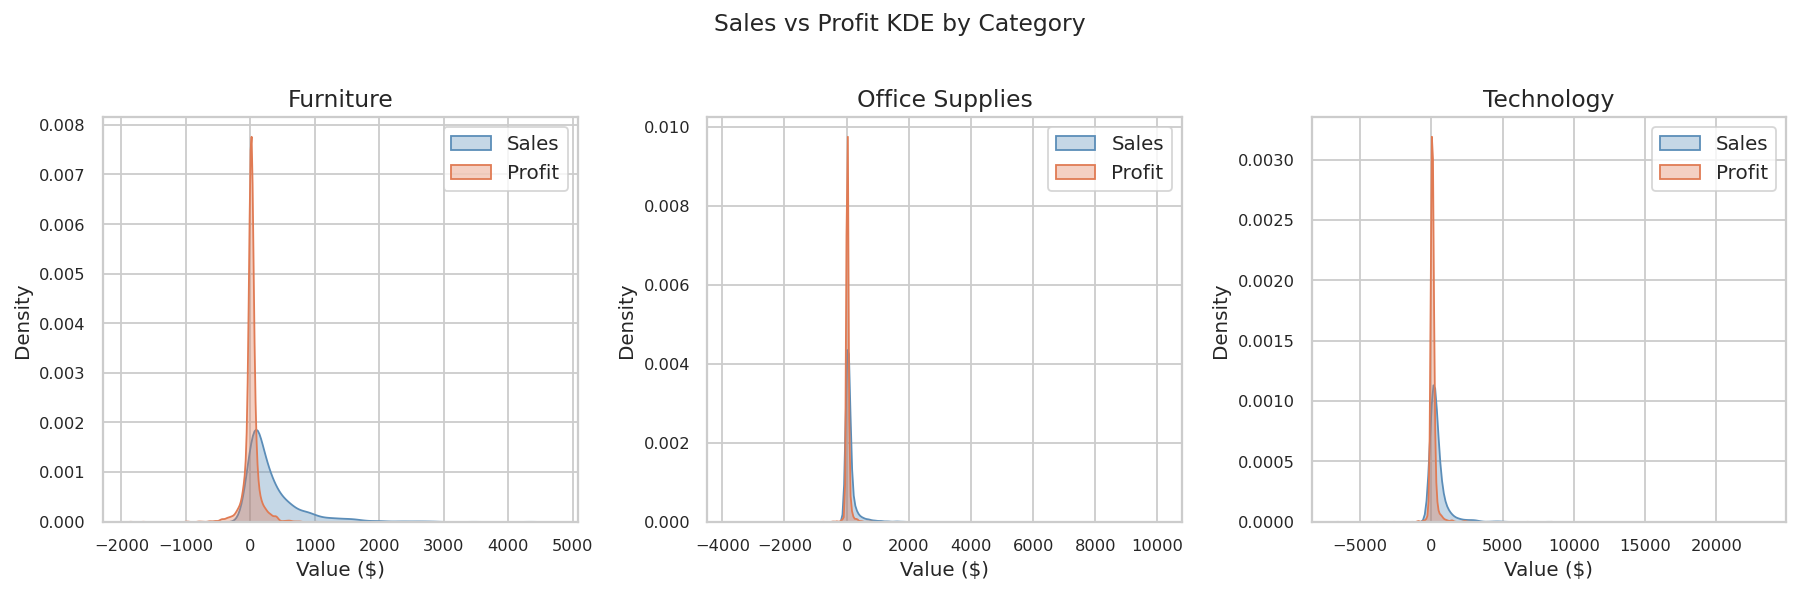

In [19]:
categories = df["Category"].unique()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, cat in zip(axes, categories):
    sub = df[df["Category"] == cat]
    sns.kdeplot(sub["Sales"],  ax=ax, label="Sales",  fill=True, alpha=0.35, color="#5B8DB8")
    sns.kdeplot(sub["Profit"], ax=ax, label="Profit", fill=True, alpha=0.35, color="#E07B54")
    ax.set_title(cat)
    ax.set_xlabel("Value ($)")
    ax.legend()

fig.suptitle("Sales vs Profit KDE by Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Insights**
- Across all categories the **Profit KDE is narrower and hugs zero** much more than Sales — costs absorb the majority of revenue in every segment.
- **Technology's** Sales KDE has the longest right tail (occasional huge deals), yet its Profit tail is comparatively modest — high revenue doesn't guarantee proportional margin.

---
## Q6 — Mean ± Std Error Bars: Profit by Sub-Category

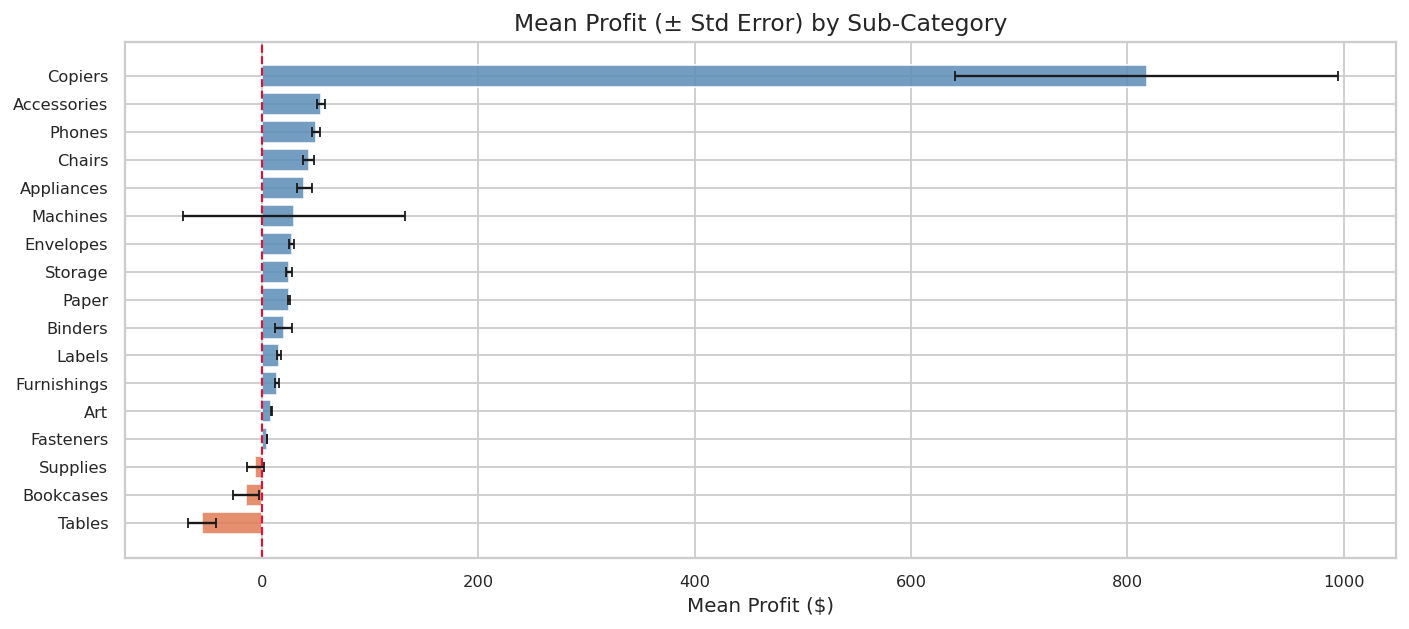

In [20]:
sub_stats = (
    df.groupby("Sub-Category")["Profit"]
      .agg(["mean", "std", "count"])
      .reset_index()
)
sub_stats["se"] = sub_stats["std"] / np.sqrt(sub_stats["count"])
sub_stats.sort_values("mean", inplace=True)

bar_colors = ["#E07B54" if m < 0 else "#5B8DB8" for m in sub_stats["mean"]]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(sub_stats["Sub-Category"], sub_stats["mean"],
        xerr=sub_stats["se"], color=bar_colors,
        error_kw={"elinewidth": 1.3, "capsize": 3}, alpha=0.85)
ax.axvline(0, color="crimson", linewidth=1.2, linestyle="--")
ax.set_title("Mean Profit (± Std Error) by Sub-Category")
ax.set_xlabel("Mean Profit ($)")
plt.tight_layout()
plt.show()

**Insights**
- **Tables** and **Bookcases** sit clearly in the red — they're structurally loss-making sub-categories, not just occasional outliers.
- **Copiers** lead with the highest average profit, but its large error bar signals high order-to-order variability — a few big deals drive that mean upward.

---
## Q7 — 3×2 Dashboard Grid

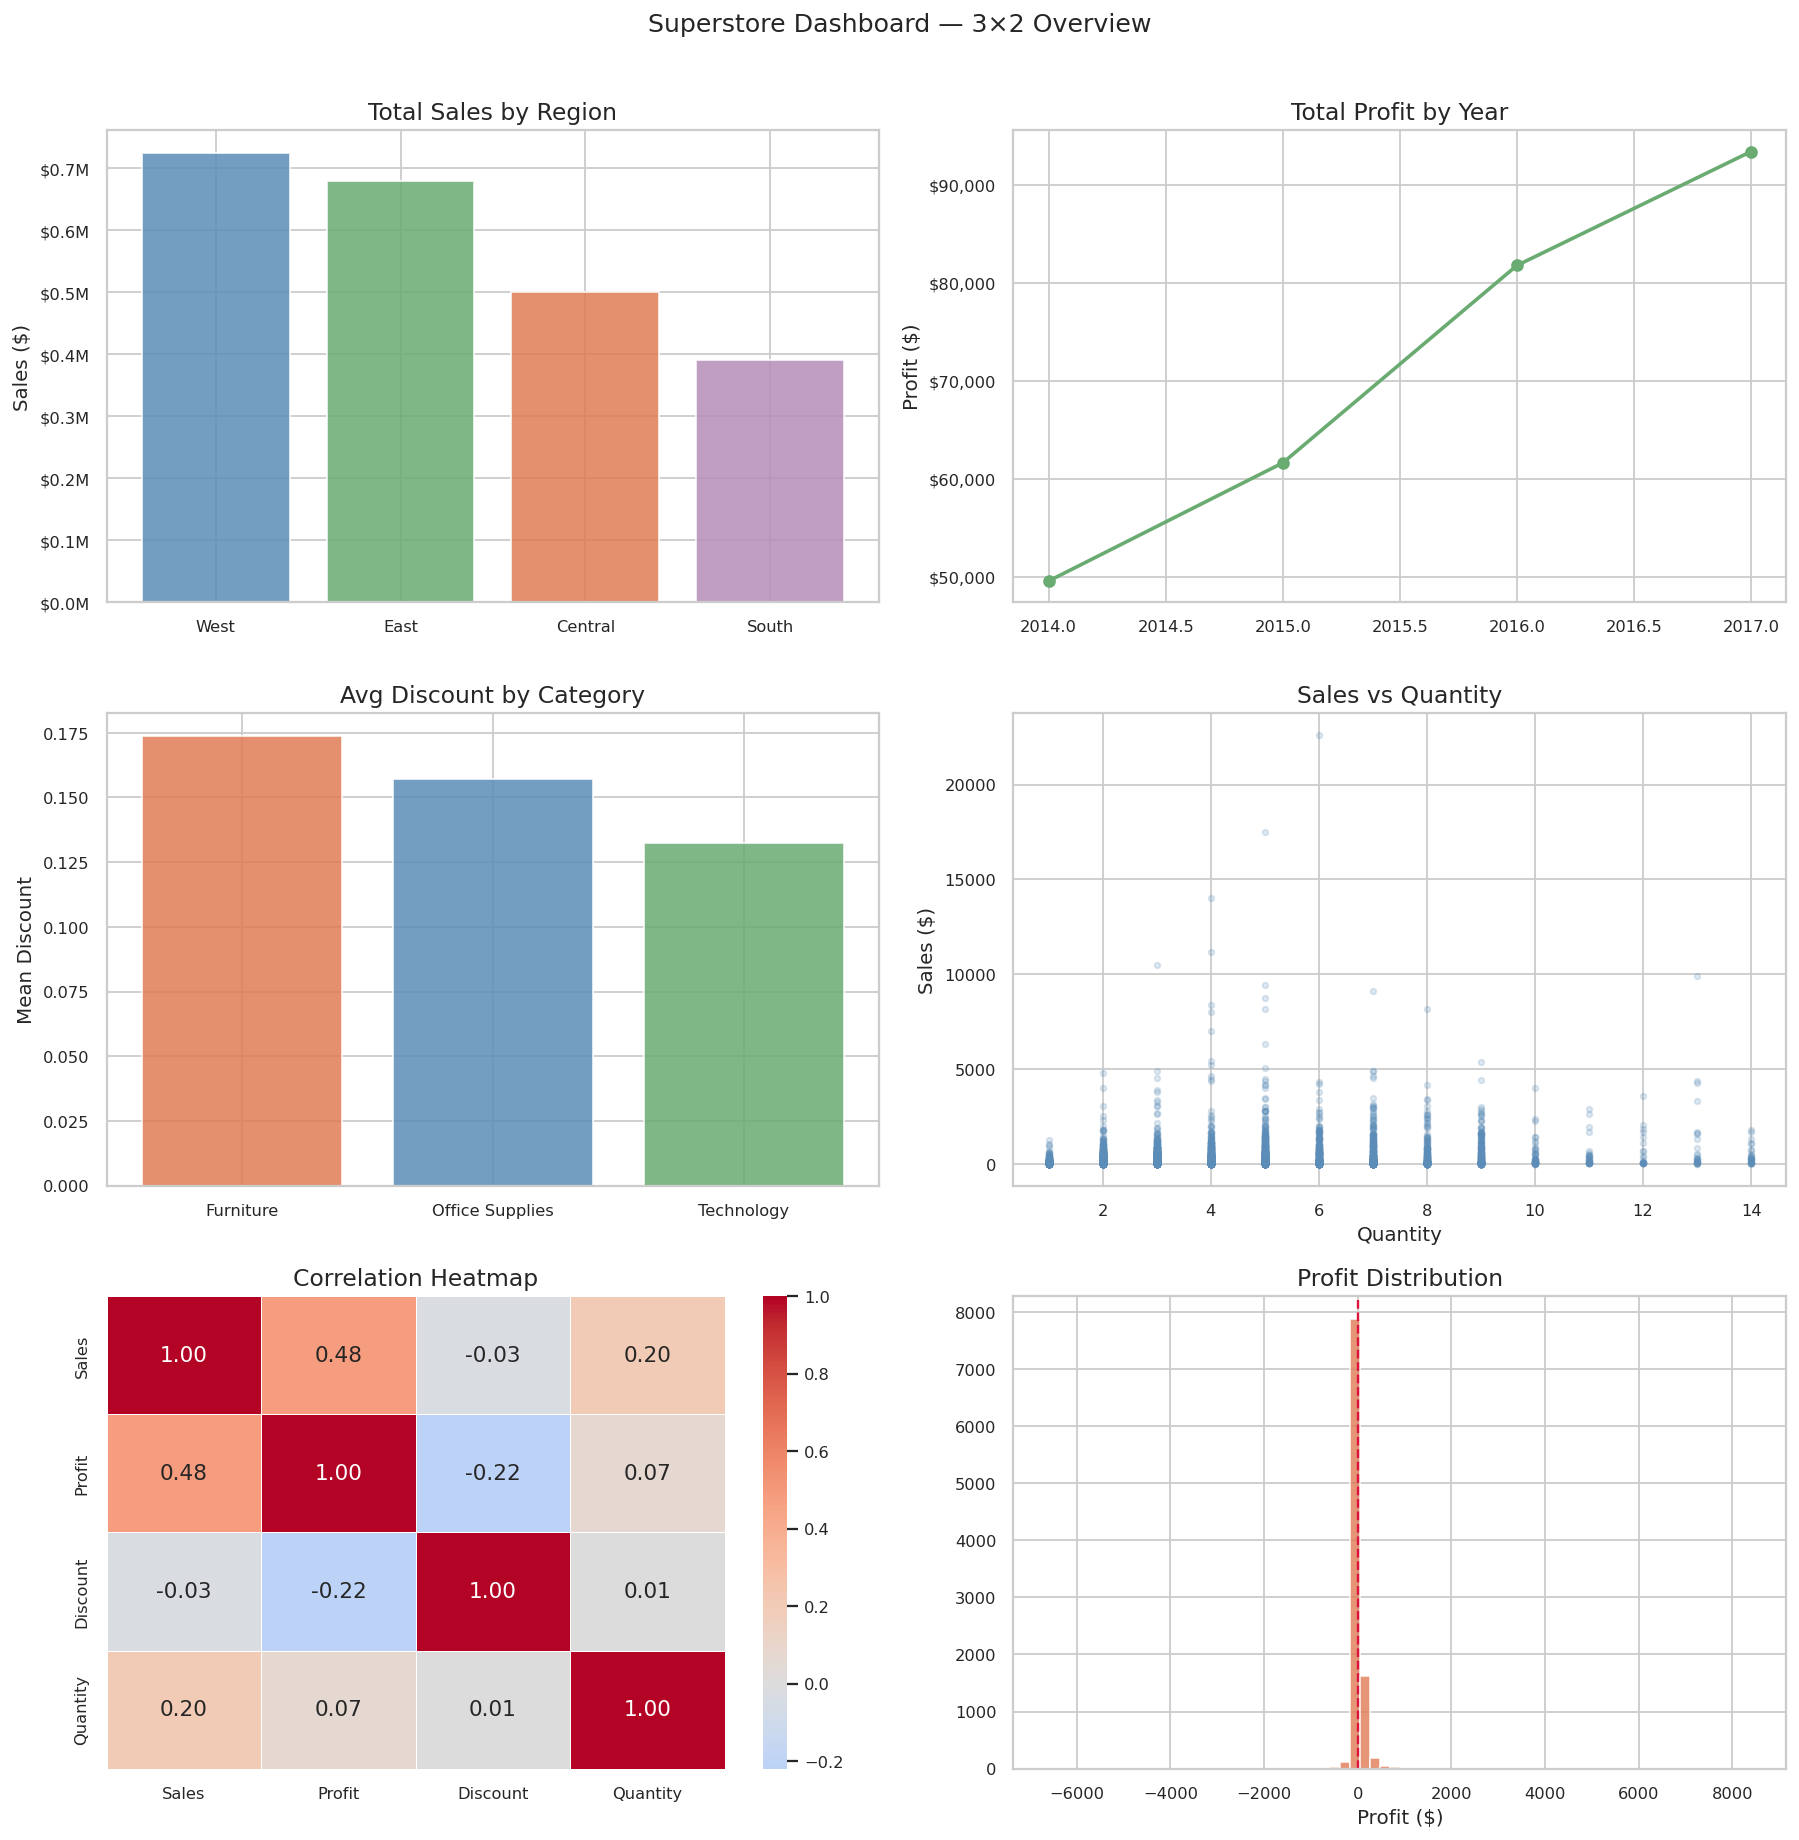

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# 7a — Sales by Region
reg_sales = df.groupby("Region")["Sales"].sum().reindex(REGIONS)
axes[0,0].bar(reg_sales.index, reg_sales.values,
              color=list(REGION_PAL.values()), alpha=0.85)
axes[0,0].set_title("Total Sales by Region")
axes[0,0].set_ylabel("Sales ($)")
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

# 7b — Profit by Year
yr_profit = df.groupby("Year")["Profit"].sum()
axes[0,1].plot(yr_profit.index, yr_profit.values,
               marker="o", color="#6AAB72", linewidth=2)
axes[0,1].set_title("Total Profit by Year")
axes[0,1].set_ylabel("Profit ($)")
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# 7c — Avg Discount by Category
cat_disc = df.groupby("Category")["Discount"].mean()
axes[1,0].bar(cat_disc.index, cat_disc.values, color=CAT_PAL, alpha=0.85)
axes[1,0].set_title("Avg Discount by Category")
axes[1,0].set_ylabel("Mean Discount")

# 7d — Sales vs Quantity
axes[1,1].scatter(df["Quantity"], df["Sales"],
                  alpha=0.2, s=10, color="#5B8DB8")
axes[1,1].set_title("Sales vs Quantity")
axes[1,1].set_xlabel("Quantity"); axes[1,1].set_ylabel("Sales ($)")

# 7e — Correlation Heatmap
num_cols = ["Sales", "Profit", "Discount", "Quantity"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[2,0], center=0, linewidths=0.5)
axes[2,0].set_title("Correlation Heatmap")

# 7f — Profit Histogram
axes[2,1].hist(df["Profit"], bins=70, color="#E07B54",
               alpha=0.8, edgecolor="white")
axes[2,1].axvline(0, color="crimson", linestyle="--", linewidth=1.3)
axes[2,1].set_title("Profit Distribution")
axes[2,1].set_xlabel("Profit ($)")

fig.suptitle("Superstore Dashboard — 3×2 Overview", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insights**
- **West** leads all regions in sales and, per the KDE analysis, in profitability too — it's the business's primary engine.
- The correlation heatmap shows **Discount ↔ Profit** as the strongest negative relationship, quantitatively confirming that the discounting policy is the main lever hurting margins.

---
## Q8 — Yearly Profit Trend by Segment with Confidence Intervals

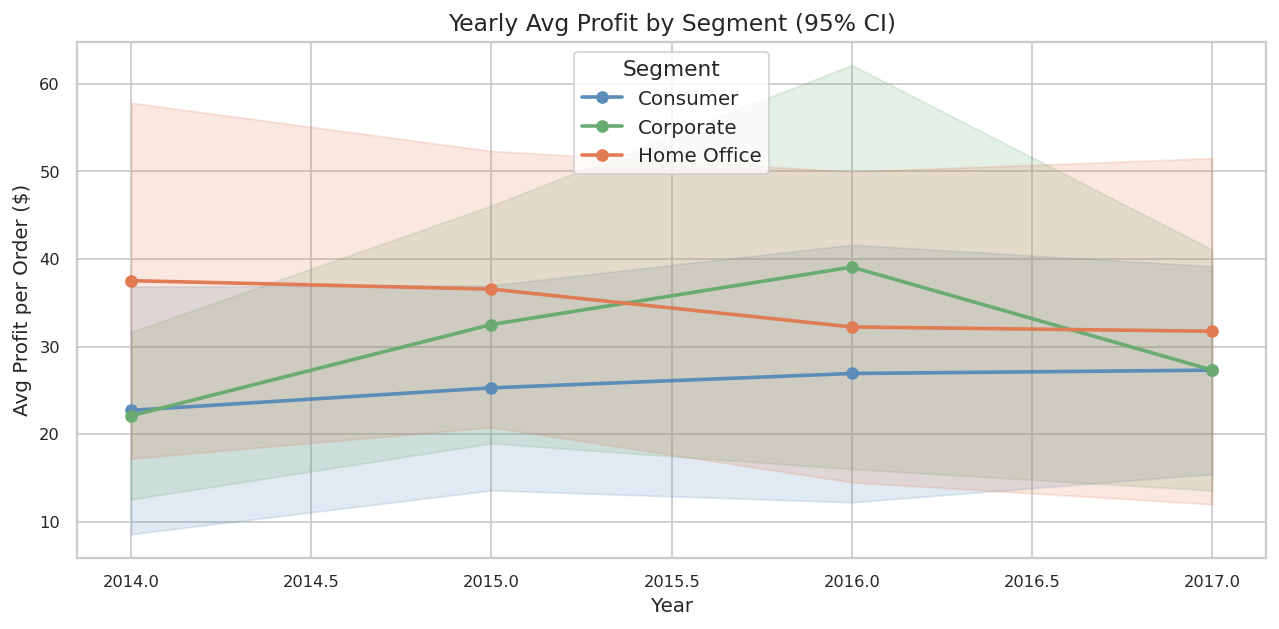

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

for seg in df["Segment"].unique():
    sub   = df[df["Segment"] == seg]
    ygrp  = sub.groupby("Year")["Profit"]
    means = ygrp.mean()
    sems  = ygrp.sem()
    years = means.index

    ax.plot(years, means, marker="o", label=seg,
            color=SEG_PAL[seg], linewidth=2)
    ax.fill_between(years,
                    means - 1.96 * sems,
                    means + 1.96 * sems,
                    alpha=0.18, color=SEG_PAL[seg])

ax.set_title("Yearly Avg Profit by Segment (95% CI)")
ax.set_xlabel("Year"); ax.set_ylabel("Avg Profit per Order ($)")
ax.legend(title="Segment")
plt.tight_layout()
plt.show()

**Insights**
- All three segments show an **upward profit trend** — the business is getting more efficient over the four-year window.
- **Home Office** has the widest confidence bands — fewer total orders means each large or unusual order swings the yearly average more dramatically.

---
## Q9 — Heatmap: Avg Profit by Sub-Category × Region

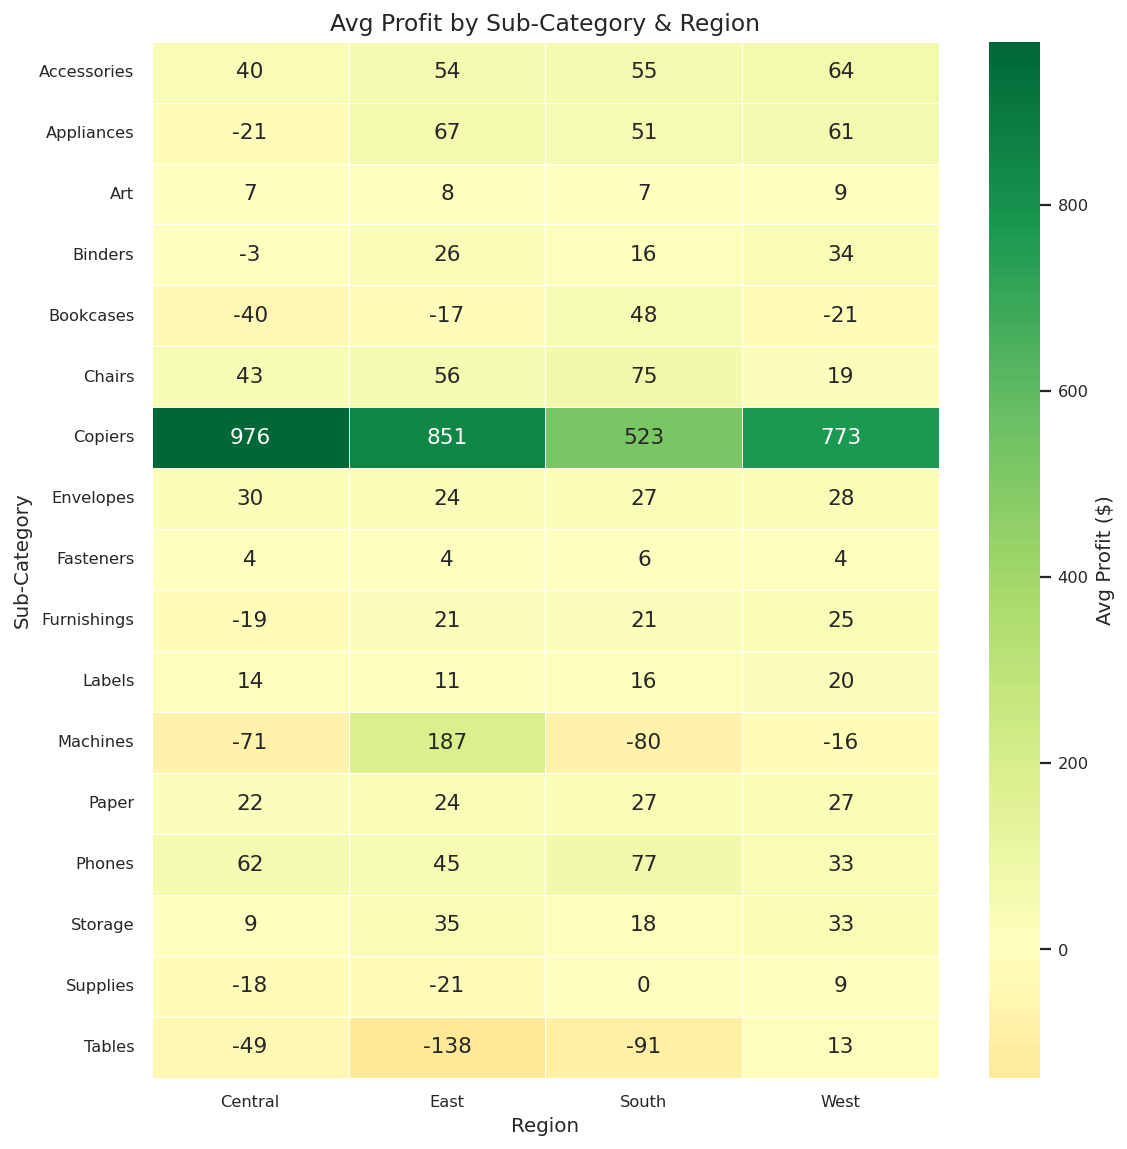

In [23]:
pivot = df.pivot_table(values="Profit", index="Sub-Category",
                       columns="Region", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn",
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={"label": "Avg Profit ($)"})
ax.set_title("Avg Profit by Sub-Category & Region")
plt.tight_layout()
plt.show()

**Insights**
- **Tables** are loss-making in every single region — no geography rescues this sub-category, pointing to a fundamental pricing or cost structure problem.
- **Copiers** perform well in West and East but weaken in Central — a regional pricing or competitive pressure issue worth investigating separately.

---
## Q10 — FacetGrid: Profit by Category × Shipping Mode

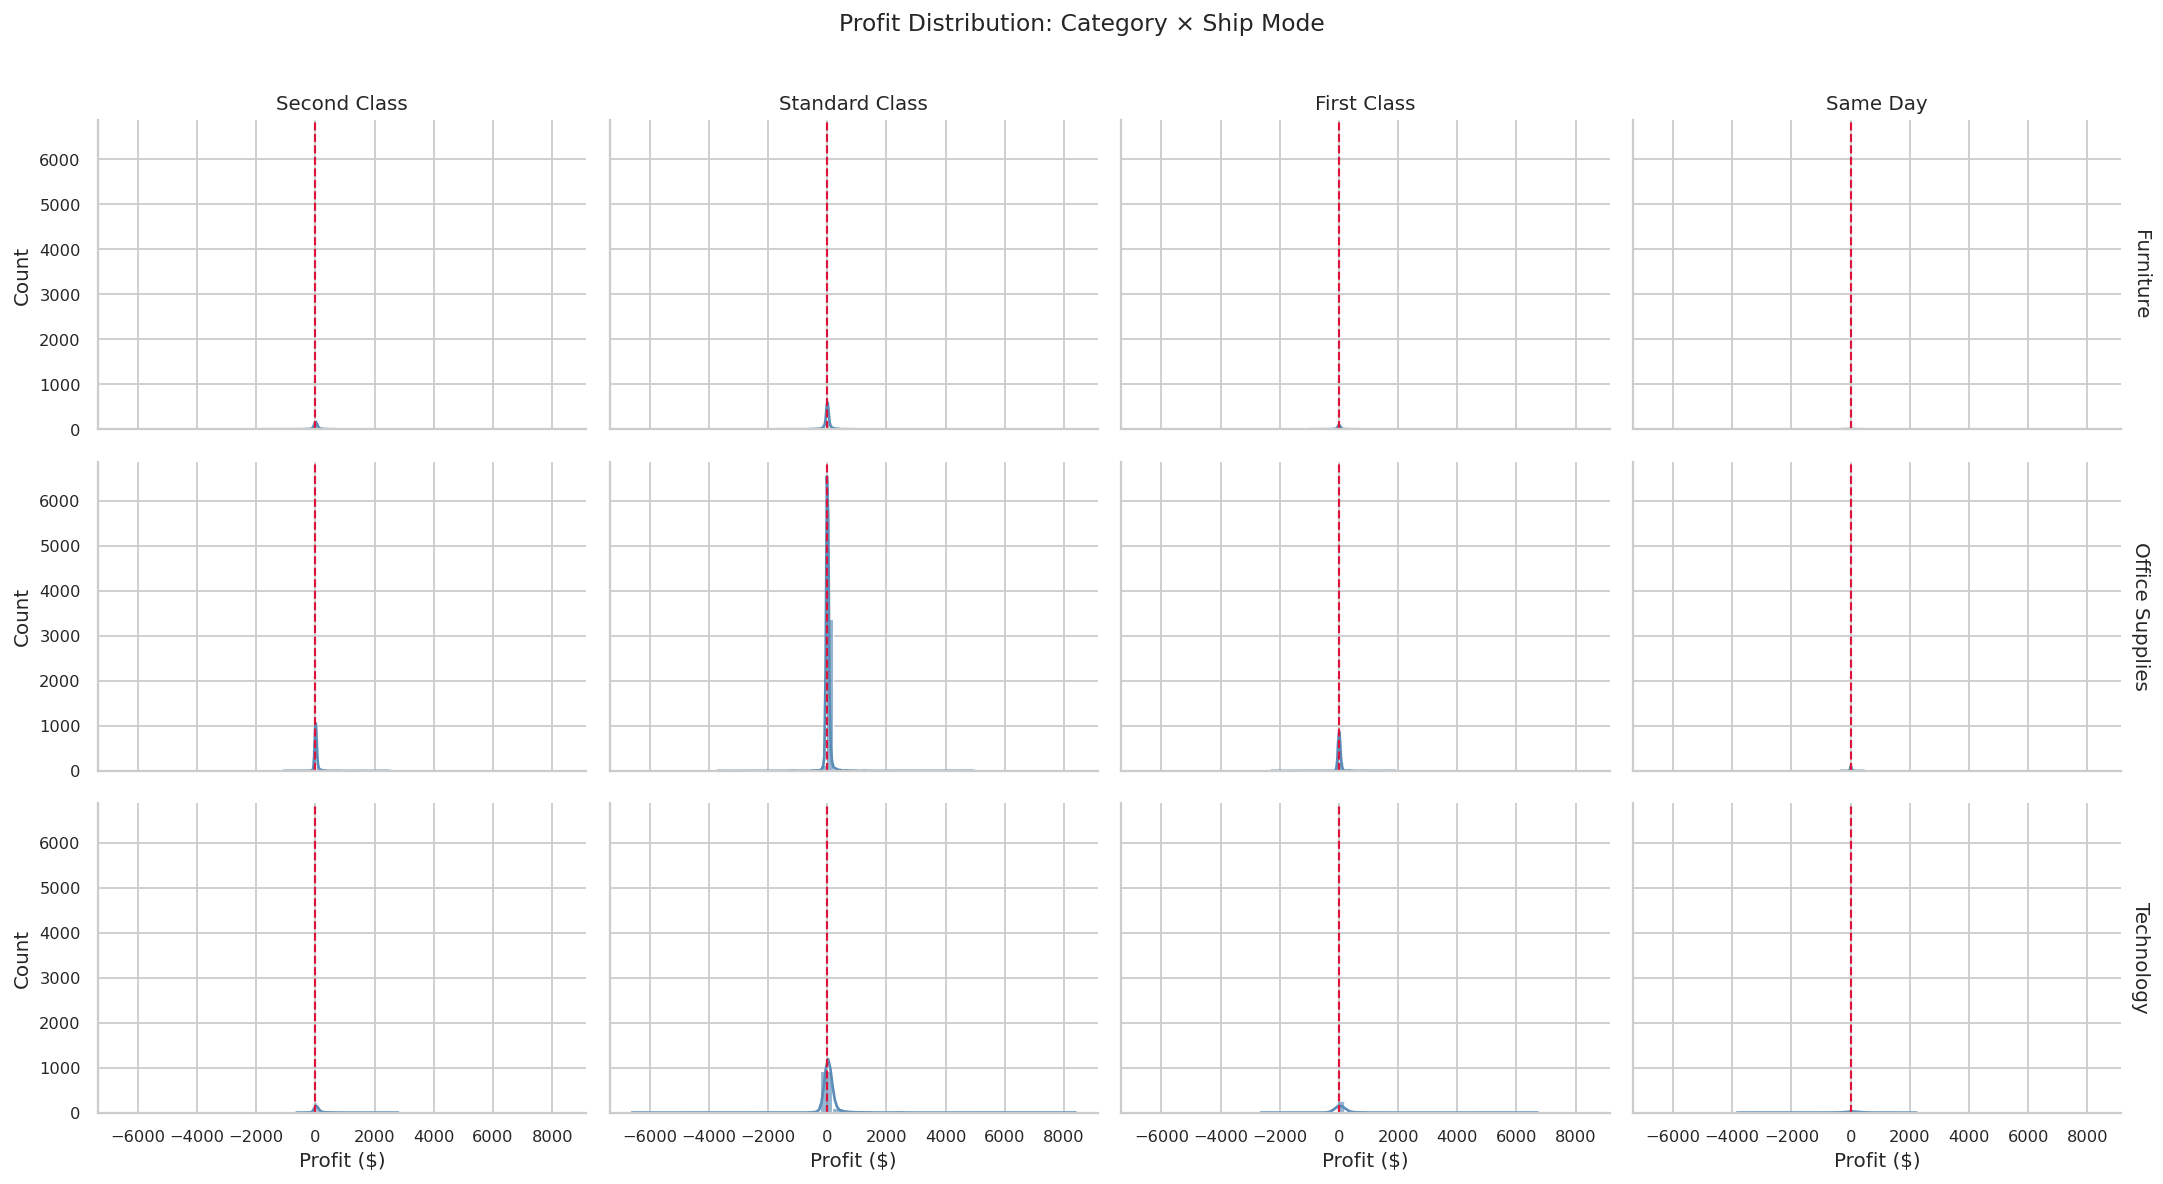

In [24]:
g = sns.FacetGrid(df, col="Ship Mode", row="Category",
                  height=3, aspect=1.4, margin_titles=True)

g.map_dataframe(sns.histplot, x="Profit",
                bins=40, kde=True, color="#5B8DB8", alpha=0.65)

g.map(plt.axvline, x=0, color="crimson", linestyle="--", linewidth=1.2)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Profit ($)", "Count")
g.figure.suptitle("Profit Distribution: Category × Ship Mode", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Insights**
- Profit profiles look nearly **identical across all shipping modes** within each category — ship mode alone doesn't drive profitability differences.
- **Furniture's** left loss-tail persists regardless of shipping choice, confirming the issue is rooted in product margin, not logistics cost.